In [1]:
import sys
sys.path.append('..')
import torch
import torch.nn.functional as F
from tqdm import tqdm
import logging
from datetime import datetime
import copy
import os

import matplotlib.pyplot as plt
from matplotlib import colors

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

In [2]:
ARC_COLORS = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40',
    '#FFDC00', '#AAAAAA', '#F012BE', '#FF851B',
    '#7FDBFF', '#870C25'
]

cmap = colors.ListedColormap(ARC_COLORS)
norm = colors.BoundaryNorm(range(11), cmap.N)

In [3]:
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()

def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()

def grid_to_string(grid):
    if hasattr(grid, 'cpu'):
        grid = grid.cpu().numpy()
    return '\n'.join(' '.join(str(int(cell)) for cell in row) for row in grid)

In [4]:
def show_triplet(input_grid, gt_grid, pred_grid, title=""):
    input_grid = input_grid.cpu().numpy()
    gt_grid = gt_grid.cpu().numpy()
    pred_grid = pred_grid.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title("Input")

    axs[1].imshow(gt_grid, cmap=cmap, norm=norm)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_grid, cmap=cmap, norm=norm)
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [5]:
def save_triplet(input_grid, gt_grid, pred_grid, save_path, title):
    input_grid = input_grid.cpu().numpy()
    gt_grid = gt_grid.cpu().numpy()
    pred_grid = pred_grid.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title("Input")

    axs[1].imshow(gt_grid, cmap=cmap, norm=norm)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_grid, cmap=cmap, norm=norm)
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

In [6]:
def safe_tta(model, sx, sy, qx, steps=10, lr=5e-4):
    local_model = copy.deepcopy(model)
    local_model.train()

    params = list(local_model.decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)

    for _ in range(steps):
        optimizer.zero_grad()

        task_tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, task_tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        task_tokens = local_model.task_encoder(sx_feat, sy_feat)

        qx_feat = local_model.encoder(qx)
        return local_model.decoder(qx_feat, task_tokens)

In [7]:
MODEL_PATH = "/home/saij/ml/arc-meta/models/arc_best.pt"
DATA_DIR = "/home/saij/ml/arc-meta/data/evaluation"
BATCH_SIZE = 4
OUTPUT_DIR = "/home/saij/ml/arc-meta/logs"

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = os.path.join(OUTPUT_DIR, f"eval_{timestamp}")
img_dir = os.path.join(log_dir, "images")

os.makedirs(img_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(os.path.join(log_dir, "eval.log")),
        logging.StreamHandler()
    ]
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [8]:
dataset = ARCTaskDataset(DATA_DIR)
loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)

model = ARCModel().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.eval()

ARCModel(
  (encoder): GridEncoder(
    (embed): Embedding(10, 128)
    (conv): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (task_encoder): TaskEncoder(
    (proj): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Decoder(
    (pre_conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (cross_attn): CrossAttentionBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  

  0%|          | 0/100 [00:00<?, ?it/s]


Task 1 | Sample 0
Pixel Acc: 0.8867 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 0 8 8 8 8 0 8 8 8 8 0 8 8 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 0 8 8 8 8 8 0 8 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 0 8 8 8 8 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 0 8 8 8 8 8 0 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 0 8 8 6 6 0 8 8 8 8 0 0 8 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 8 8 8 6 6 8 0 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 8 0 0 8 8 8 8 8 8 0 0 8 8 0 0 0 0 0 0 0 0 0 0 0
0 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

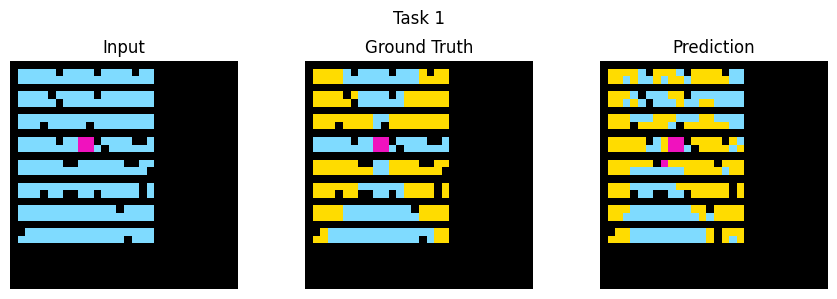


Task 2 | Sample 0
Pixel Acc: 0.8833 | Task Acc: 0.0000

Input:
 1 8 2 8 9 7 9 7 7 9 7 9 8 2 8 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 8 1 1 7 9 1 1 1 1 9 7 1 1 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0
2 1 1 2 9 1 9 9 9 9 1 9 2 1 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 1 2 8 7 1 9 9 9 9 1 7 8 2 1 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0
9 7 9 7 8 6 8 6 6 8 6 8 7 9 7 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 3 3 3 6 4 6 8 8 6 4 6 1 1 9 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0
9 3 3 3 8 6 6 6 6 6 6 8 9 9 1 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 3 3 3 6 8 6 8 8 6 8 6 9 9 1 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 3 3 3 6 8 6 8 8 6 8 6 9 9 1 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0
9 1 9 9 8 6 6 6 6 6 6 8 9 9 1 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7 3 3 3 3 4 6 8 8 6 4 6 1 1 9 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0
9 3 3 3 3 6 8 6 6 8 6 8 7 9 7 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 1 2 8 7 1 9 9 9 9 1 7 8 2 1 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0
2 1 1 2 9 1 9 9 9 9 1 9 2 1 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 8 1 1 7 9 1 1 1 1 9 7 1 1 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 8 2 8 9 7 9 7 7 9 7 9 8 2 8 1 0 0

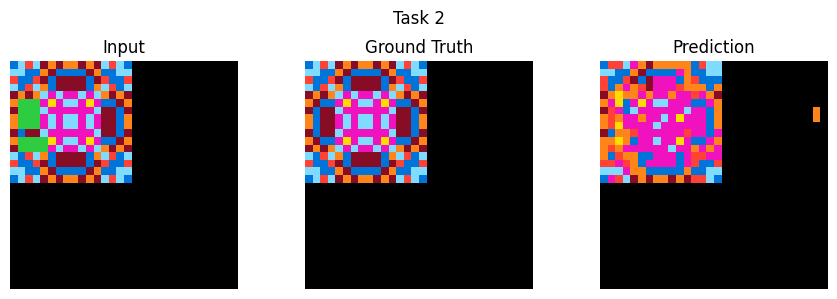


Task 3 | Sample 0
Pixel Acc: 0.9811 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 2 2 2 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 3 3 3 3 3 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 6 6 6 6 6 6 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 6 6 6 6 6 6 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 6 6 6 6 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 6 6 6 6 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 6 6 6 6 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 6 6 6 6 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

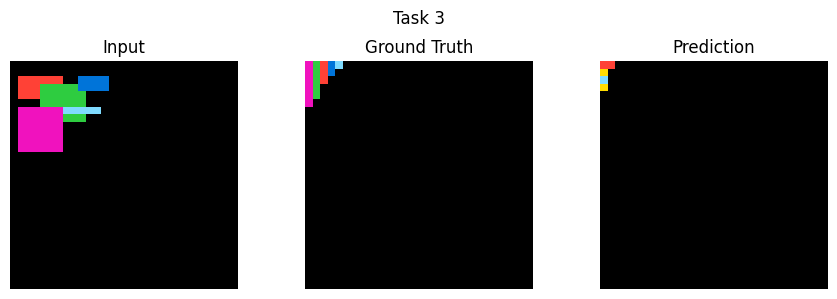


Task 4 | Sample 0
Pixel Acc: 0.9733 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
3 3 4 6 6 6 9 9 7 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

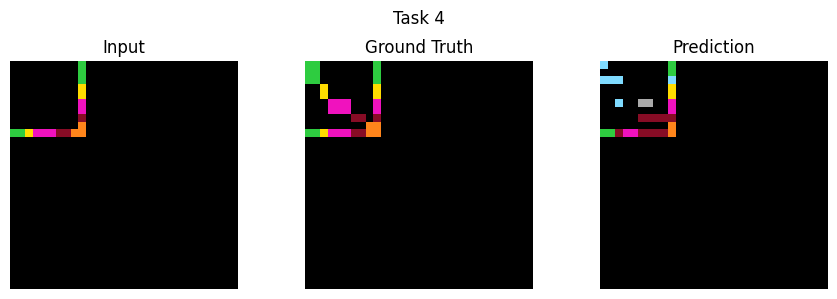

  1%|          | 1/100 [00:07<12:36,  7.64s/it]


Task 5 | Sample 0
Pixel Acc: 0.9733 | Task Acc: 0.0000

Input:
 2 2 0 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
2 2 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
2 2 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
5 0 5 0 0 5 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
5 5 5 5 5 5 5 5 5 5 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

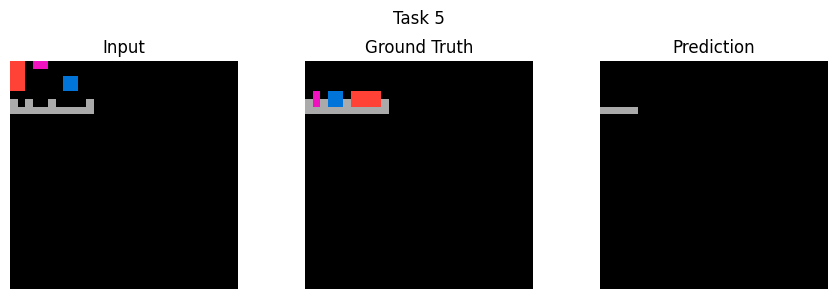


Task 6 | Sample 0
Pixel Acc: 0.5078 | Task Acc: 0.0000

Input:
 5 4 3 2 4 3 2 1 5 4 3 2 4 3 2 1 5 4 3 2 4 3 2 1 5 4 3 0 0 0
4 5 6 7 7 8 9 1 4 5 6 7 7 8 9 1 4 5 6 7 7 8 9 1 4 5 6 0 0 0
3 6 9 3 1 4 7 1 3 6 9 3 1 4 7 1 3 6 9 3 1 4 7 1 3 6 9 0 0 0
2 7 3 8 4 0 0 0 0 7 3 8 4 9 5 1 2 7 3 8 4 9 5 1 2 7 3 0 0 0
4 7 1 4 1 0 0 0 0 7 1 4 1 4 7 1 4 7 1 4 1 4 7 1 4 7 1 0 0 0
3 8 4 9 4 0 0 0 0 8 4 9 4 9 5 1 3 8 4 9 4 9 5 1 3 8 4 0 0 0
2 0 0 0 0 0 0 0 0 9 7 5 7 5 3 1 2 9 7 5 7 5 3 1 2 9 7 0 0 0
1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0
5 0 0 0 0 0 2 1 5 4 3 2 4 3 2 1 5 4 3 2 4 3 2 1 0 0 3 0 0 0
4 0 0 0 0 0 9 1 4 5 6 7 7 8 9 1 4 5 6 7 7 8 9 1 0 0 6 0 0 0
3 0 0 0 0 0 7 1 3 6 9 3 1 4 7 1 3 6 9 3 1 4 7 1 0 0 9 0 0 0
2 0 0 0 0 0 5 1 2 7 3 8 4 0 0 0 0 0 0 8 4 9 5 1 2 7 3 0 0 0
4 7 1 4 1 4 7 1 4 7 1 4 1 0 0 0 0 0 0 4 1 4 7 1 4 7 1 0 0 0
3 8 4 9 4 9 5 1 3 8 4 9 4 9 5 1 3 8 4 9 4 9 5 1 3 8 4 0 0 0
2 9 7 5 7 5 3 1 2 9 7 5 7 5 3 1 2 9 7 5 7 5 3 1 2 9 7 0 0 0
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

  2%|▏         | 2/100 [00:09<06:45,  4.14s/it]


Task 9 | Sample 0
Pixel Acc: 0.8878 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 0 0 0 0
0 5 2 2 5 0 5 2 2 5 0 5 2 3 5 0 5 2 2 5 0 5 2 2 5 0 0 0 0 0
0 5 5 8 5 0 5 5 2 5 0 5 5 2 5 0 5 5 2 5 0 5 5 2 5 0 0 0 0 0
0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 0 0 0 0
0 5 2 2 5 0 5 2 2 5 0 5 2 2 5 0 5 2 2 5 0 5 2 2 5 0 0 0 0 0
0 5 5 2 5 0 5 5 4 5 0 5 5 2 5 0 5 5 4 5 0 5 5 2 5 0 0 0 0 0
0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 0 0 0 0
0 5 2 2 5 0 5 2 2 5 0 5 2 2 5 0 5 2 2 5 0 5 2 2 5 0 0 0 0 0
0 5 5 2 5 0 5 5 2 5 0 5 5 2 5 0 5 5 2 5 0 5 5 2 5 0 0 0 0 0
0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 5 5 5 5 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

  3%|▎         | 3/100 [00:10<04:38,  2.87s/it]


Task 13 | Sample 0
Pixel Acc: 0.9822 | Task Acc: 0.0000

Input:
 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 0 5 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 5 0 3 0 0 0 0 8 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
5 5 5 5 0 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 4 0 0 6 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 9 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 8 7 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 7 0 0 7 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 4 1 0 0 0 6 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 4 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 9 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

...

 98%|█████████▊| 98/100 [02:51<00:03,  1.58s/it]


Task 392 | Sample 0
Pixel Acc: 0.9356 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 7 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

 99%|█████████▉| 99/100 [02:53<00:01,  1.52s/it]


Task 396 | Sample 0
Pixel Acc: 0.4756 | Task Acc: 0.0000

Input:
 8 8 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
6 3 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
6 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

100%|██████████| 100/100 [02:54<00:00,  1.75s/it]


In [9]:
total_pixel_acc = 0
total_task_acc = 0
count = 0

MAX_VIS = 5  # limit display

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(device)
    support_y = batch["support_y"].to(device)
    query_x = batch["query_x"].to(device)
    query_y = batch["query_y"].to(device)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len].long()
        sy = support_y[b, :s_len].long()
        qx = query_x[b, :q_len].long()
        qy = query_y[b, :q_len].long()

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        pred = safe_tta(model, sx, sy, qx)

        h, w = qy.shape[-2:]
        pred = pred[:, :, :h, :w]

        pred_classes = pred.argmax(dim=1)

        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel_acc += p_acc
        total_task_acc += t_acc
        count += 1

        for i in range(qx.shape[0]):

            print("\n" + "=" * 50)
            print(f"Task {count} | Sample {i}")
            print(f"Pixel Acc: {p_acc:.4f} | Task Acc: {t_acc:.4f}")

            print("\nInput:\n", grid_to_string(qx[i][0]))
            print("\nGT:\n", grid_to_string(qy[i][0]))
            print("\nPred:\n", grid_to_string(pred_classes[i]))

            # show inline
            if count <= MAX_VIS:
                show_triplet(
                    qx[i][0],
                    qy[i][0],
                    pred_classes[i],
                    title=f"Task {count}"
                )

            # save image
            save_path = os.path.join(
                img_dir,
                f"task_{count}_sample_{i}.png"
            )

            save_triplet(
                qx[i][0],
                qy[i][0],
                pred_classes[i],
                save_path,
                title=f"Task {count} | Pixel={p_acc:.3f}"
            )

In [10]:
if count > 0:
    print("\n" + "=" * 50)
    print(f"Final Pixel Accuracy: {total_pixel_acc / count:.4f}")
    print(f"Final Task Accuracy:  {total_task_acc / count:.4f}")
    print("=" * 50)
else:
    print("No tasks evaluated.")


Final Pixel Accuracy: 0.9135
Final Task Accuracy:  0.0025
